# **Exercise 4**: Add subgrid tables to your model

In this exercises we will add subgrid tables to the model we created in the previous exercise. We will also use the subgrid functionality to downscale our floodmaps to a higher resolution. The steps to do so are:
- Step 1: Read the Charleston model a change the output root
- Step 2: Create subgrid tables using our high resolution topobathy data and using the ESA worldcover land cover data.
- Step 3: Run the model again
- Step 4: Downscale and visualize the maximum water levels to subgrid resolution


## **Step 0:** Import dependencies

Before anything else we need to import the required packages

In [1]:
from pathlib import Path

from hydromt.log import setuplog
from hydromt_sfincs import SfincsModel, utils
from sfincs_plotting import make_interactive_plot
from sfincs_utils import run_sfincs

## default answers (for testing)

In [ ]:
# step 1
model_root_old = 'sfincs_charleston'
model_root = 'sfincs_charleston_subgrid'

# step 2
charleston_dem_source = 'topography_charleston'
nr_subgrid_pixels = 10 # 10 cells within the 200m grid (so 20x20m resolution)



## **Step 1:** Read the model a change the output root
Now let's copy our old model to a new folder, so we can always look at the old model later on:

In [3]:
# model_root_old = 'YOUR_OLD_MODEL_ROOT'
# model_root = 'YOUR_NFW_MODEL_ROOT'

logger = setuplog('SFINCS_log_charleston', log_level=20)
sf = SfincsModel(data_libs=['data_catalog.yml'], root=model_root_old, mode='r', logger=logger)
sf.read()

# change the model root (to not overwrite existing model)
sf.set_root(model_root, mode= 'r+')

2025-12-19 13:26:21,938 - SFINCS_log_charleston - log - INFO - HydroMT version: 0.10.1
2025-12-19 13:26:21,994 - SFINCS_log_charleston - data_catalog - INFO - Parsing data catalog from data_catalog.yml
2025-12-19 13:26:22,050 - SFINCS_log_charleston - model_api - INFO - Initializing sfincs model from hydromt_sfincs (v1.2.2).
2025-12-19 13:26:23,057 - SFINCS_log_charleston - sfincs - WARNING - Index in bndfile does not match c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston\gis\bnd.geojson
2025-12-19 13:26:23,073 - SFINCS_log_charleston - sfincs - WARNING - Index in bndfile does not match c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston\gis\bnd.geojson
2025-12-19 13:26:23,272 - SFINCS_log_charleston - sfincs - INFO - Model read


## **Step 2:** Subgrid Tables

So far our model uses the grid we specified with the resolution we specified, in this case 200m. This means we are not making optimal use of our DEM as a grid cell is much larger than the DEM resolution. Increasing the grid resolution however is not a good idea as the computing time scales with the 3rd power of the grid size.

Instead we make use of a so-called subgrid. The idea is that for a given water level in a grid cell we calculate a more realistic water volume in the cell using the high-res DEM. The water flow is only calculated between regular grid cells but using these new water volumes. Computationally this is much more efficient.

To setup the subgrid we need to provide the relevant topographical data. These are the high-res DEM, the roughness data (not strictly needed, a default will be used when no argument is provided), and river data (although we don't use this in our example). Finally we need to specify the number of subgrid cells in each grid cell (lateral size, total nr of subgrid pixels per cell is `nr_subgrid_pixels`<sup>2</sup>). This we want to match our DEM resolution as close as possible. In our example the grid resolution is 200m while the DEM resolution is 10m, meaning we could use a value of 20 for the `nr_subgrid_pixels`. This might however take a bit longer to create, so for now let's stick to a value of 10, so our subgrid cells are 20x20m

For all possible options to add to the `setup_subgrid` function see:
https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.SfincsModel.setup_subgrid.html

Finally we write the elevation subgrid data.

Creating the subgrid may take a few minutes

In [4]:
# charleston_dem_source = 'YOUR_LOCAL_TOPOGRAPHY_DATACATALOG_KEY'
datasets_dep = [
    {'elevtn': charleston_dem_source}, 
    {'elevtn': 'copdem30', 'zmin' : 0.001}, 
    {'elevtn': 'gebco'}
]
datasets_rgh = [
    {'lulc': 'esa_worldcover', 'reclass_table': 'esa_worldcover_mapping'}
]

sf.setup_subgrid(
    datasets_dep= datasets_dep,
    datasets_rgh = datasets_rgh,
    nr_subgrid_pixels = nr_subgrid_pixels,  #Fill in number of subgrid files
    write_dep_tif=True,  # save a cloud-optimized geotiff of the subgrid topography
    write_man_tif=False,
    nrmax=5000,  # set tile size a bit larger speed up processing (default 2000)
)
# make sure to write the updated model to the new model root before running sfincs
sf.write()

2025-12-19 13:32:17,541 - SFINCS_log_charleston - rasterdataset - INFO - Reading topography_charleston raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\topography_charleston_10m.tif
2025-12-19 13:32:17,825 - SFINCS_log_charleston - rasterdataset - INFO - Reading copdem30 raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\copdem30.tif
2025-12-19 13:32:17,870 - SFINCS_log_charleston - rasterdataset - INFO - Reading gebco raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\gebco.tif
2025-12-19 13:32:17,905 - SFINCS_log_charleston - rasterdataset - INFO - Reading esa_worldcover raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\esa_worldcover.tif
2025-12-19 13:32:17,934 - SFINCS_log_charleston - dataframe - INFO - Reading esa_worldcover_mapping csv data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\esa_worldcover_mapping.csv
2025-12-19 13:32:17,998 - SFINCS_log_charleston - subgrid - INFO - N

## **Step 3:** Rerun the model, using the new subgrid tables

In [6]:
# NOTE you need to download the SFINCS executable first (see first notebook) and update the path below
sfincs_exe = Path("../../00_software/SFINCS_2025_02_release", "SFINCS_v2.3.0_mt_Faber_release_exe", "sfincs.exe")

run_sfincs(
    sf.root, # path to the SFINCS model root folder
    sfincs_exe=sfincs_exe, # path to the sfincs executable if you want to run SFINCS on windows
    vm=None, # you can use 'docker' if you want to run SFINCS on linux or mac, but you need to install docker desktop first
)

>> c:\PhD\SFINCS\SFINCS_Charleston\00_software\SFINCS_2025_02_release\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@....

### Question 1
Now check the computation time of your model run: 
a) how does it compare with the original model? 

*Hint:* You check the total computation time in the logging of your model run (*sfincs_log.txt*); navigate to the model folder and open the text file. Here your see the total run time and the time that the model spent in each module. Compare these times with the *sfincs_log.txt* file from your original model

#### Fill in your own answers:

1a)

## **Step 4:** Visualize the results on subgrid resolution

When subgrid tables are used, these are based on elevation data of a resolution higher than the resolution of the computational grid. The bed levels stored in the NetCDF output (zb in sfincs_map.nc) are the minimum bed levels from the subgrid tables of each computational cell. Therefore, to properly derive water depths, the higher resolution elevation data should be used instead of simply using the bed levels from the model output (this would result in an overestimation of flood extents). The process of interpolating the water levels onto the higher-resolution elevation data is called downscaling.

The downscaling of the floodmap roughly includees the following steps:

1. Select your high-resolution elevation dataset

2. Retrieve the maximum water levels from your model

3. Determine if and how you want to mask your floodmap

4. Write a geotiff of your downscaled floodmap

5. Plot your downscaled floodmap here, or in QGIS

More information about the downscale_floodmap function can be found here: https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.utils.downscale_floodmap.html


In [7]:
# first we are going to select our subgrid-resolution elevation dataset
depfile = Path(sf.root, 'subgrid', 'dep_subgrid.tif')
dep = sf.data_catalog.get_rasterdataset(depfile)

2025-12-19 13:36:08,040 - SFINCS_log_charleston - rasterdataset - INFO - Reading  raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\subgrid\dep_subgrid.tif


In [9]:
# secondly we are reading in the model results
sf.read_results()

# now assuming we have a subgrid model, we don't have hmax available, so we are using zsmax (maximum water levels)
zsmax = sf.results["zsmax"]

# compute the maximum over all time steps
zsmax = zsmax.max(dim='timemax')

2025-12-19 13:44:28,446 - SFINCS_log_charleston - model_api - WARNING - Replacing result: inp
2025-12-19 13:44:28,447 - SFINCS_log_charleston - model_api - WARNING - Replacing result: msk
2025-12-19 13:44:28,448 - SFINCS_log_charleston - model_api - WARNING - Replacing result: qinf
2025-12-19 13:44:28,450 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zb
2025-12-19 13:44:28,451 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zs
2025-12-19 13:44:28,452 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zsmax
2025-12-19 13:44:28,453 - SFINCS_log_charleston - model_api - WARNING - Replacing result: total_runtime
2025-12-19 13:44:28,454 - SFINCS_log_charleston - model_api - WARNING - Replacing result: average_dt
2025-12-19 13:44:28,455 - SFINCS_log_charleston - model_api - WARNING - Replacing result: status


In [8]:
# uncomment to check method docstring for more info
# utils.downscale_floodmap?

In [10]:
# Thirdly, we downscale the floodmap and write it to a geotiff
gdf_osm = sf.data_catalog.get_geodataframe('osm_landareas')
floodmap_fn=Path(model_root, "subgrid", "floodmap.tif")

hmax = utils.downscale_floodmap(
    zsmax=zsmax,
    dep=dep,
    hmin=0.10,
    # gdf_mask=gdf_osm,  #you can turn this on
    floodmap_fn=floodmap_fn,
    logger=logger,
)

2025-12-19 13:45:13,128 - SFINCS_log_charleston - geodataframe - INFO - Reading osm_landareas vector data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\osm_landareas.gpkg
2025-12-19 13:45:15,174 - SFINCS_log_charleston - utils - INFO - Building 4 overviews with nearest


We know created a geotif file with the downscaled floodmaps. With the function below we can view the geotif interactively within the notebook. Fill in the path of your geotif and run the cell below. 

*Hint* you can ignore the error message that the holoviews function gives.

In [12]:
# # View the floodmap interactively
# make_interactive_plot(
#     da_fn=floodmap_fn,
#     bmap='Satellite',
#     title='TITLE', 
#     vmax=3
# )

### Question 2

2a) Check the size of the cells, does it agree with your expectation?

2b) Why do you think if you zoom in, the results on land look less smooth and 'tiled'?

2c) Can you identify from the floodmap where the high resolution topography data ends?

2d) You can mask the flood map so you only see data on land, as known by OpenStreetMaps, by including the line 'gdf_mask=gdf_osm' in downscale_floodmap, does this match your expectation?

#### Fill in your own answers:

2a)

2b)

2c)

2d)

### IMPORTANT NOTE 
While it's great that you can very quickly run a SFINCS simulation on a course 200 m grid, and downscale the final floodmap to e.g. 1m resolution that looks pretty, the original simulation was still relatively course, despite using the subgrid functionality.

In your own project, always look whether the level of you detail you need to resolve matches with your flux grid resolution.
You might want the increase the resolution (and wait a little bit longer on the outcome of your simulation.)

## **What's Next:** Add river inflow

If you are finished with the exercises above, you can continue with the next notebook: *SFINCS_course_05_river_inflow.ipynb*. In this notebook we will add river inflow points and discharge timeseries as upstream boundaries to the model. 

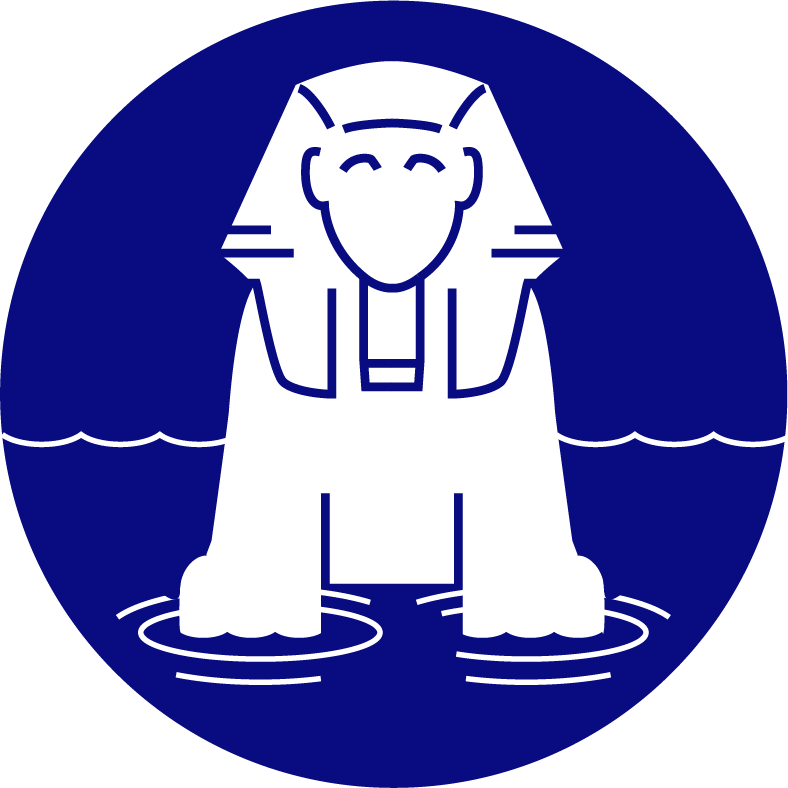